In [40]:
# === Standard Libraries ===
import os
import numpy as np
import pandas as pd
import scipy
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm import tqdm
import pyBigWig as pbw
import logging
logging.getLogger().setLevel(logging.INFO)

# === PyTorch ===
import torch
from torch.utils.data import DataLoader

# === Tangermeme
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise
from tangermeme.io import read_meme
from tangermeme.annotate import annotate_seqlets, count_annotations
from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets

# === Vinson Package ===
from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.io import SamplesDensityExtractor
from vinson.utils import intervals_to_ohe
from vinson.models.helpers import _Exp
from vinson.datasets.sequence import SequenceEmbedDataset
from vinson.loss import poisson_loss, mse_loss
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel

# === Genome Tools ===
from genome_tools import GenomicInterval
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

# === Plotting ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



In [ ]:
#chunk1998_5997_1
#in Muscle in human, and Liver/Hepatic in mouse
chunk1565_2917_2
human Epithelium
mouse Monocyte
chunk1435_3043_5, cmp panc

In [206]:
pearson_df = pd.read_table('/home/mbrannon/tmp/ag_preds_nll_mouse/metrics_summary.txt')


In [238]:
pearson_df = pd.read_table('/home/mbrannon/tmp/ag_preds_nll/metrics_summary.txt')

In [239]:
pearson_df=pearson_df.rename(columns={'AG_ID':"ag_id"})

In [240]:
meta = pd.read_table('/home/mbrannon/tmp/ag_metadata.tsv')

In [208]:
meta = pd.read_table("/home/mbrannon/mouse_dnase_250910.tsv")

In [241]:
m = meta[['ag_id','extended_annotation']]

In [242]:
merged = pearson_df.merge(m, on="ag_id")


In [243]:
merged

,ag_id,Pearson,Mean_NLL,extended_annotation
0,AG10034,0.4772,0.0829,CML
1,AG10033,0.6091,0.0659,CML
2,AG10036,0.6615,0.0853,CML
3,AG10040,0.6568,0.2551,CML
4,AG10039,0.6049,0.0740,CML
...,...,...,...,...
4141,AG80203,0.6466,0.2090,Carcinoma
4142,AG80758,0.5579,0.2369,Fibroblast
4143,AG80158,0.5359,0.2424,Epithelium
4144,AG80500,0.6806,0.1496,Fibroblast


In [244]:
tcell_df = merged[merged["extended_annotation"].str.contains("cmp", case=False)]

# Find the lowest Pearson r
lowest_tcell = tcell_df.loc[tcell_df["Mean_NLL"].idxmin()]

print(lowest_tcell)


ag_id                  AG72805
Pearson                 0.7293
Mean_NLL                0.0832
extended_annotation        CMP
Name: 1811, dtype: object


In [98]:
# Create model
embed = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = EmbedModel(trunk, embed, regression=True)

In [12]:
pretrained_state_dict = torch.load(
    "/home/jvierstra/proj/vinson/models/data_AUG3_with_warmup_and_decay_v2/checkpoints/epoch=3-step=1851994-val_loss=16.16.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

model.load_state_dict(pretrained_state_dict)

/tmp/ipykernel_22912/292516220.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_state_dict = torch.load(


<All keys matched successfully>

In [13]:
model = model.eval()


In [14]:
dhses = pd.read_csv("/home/mbrannon/tmp/dhs_region.csv")

In [245]:
dhses[dhses['dhs_id']=='chunk1435_3043_5']

,dhs_id,chrom,start,end
425,chunk1435_3043_5,chr2,157786870,157787156


In [247]:
merged[merged['ag_id']=='AG72805']

,ag_id,Pearson,Mean_NLL,extended_annotation
1811,AG72805,0.7293,0.0832,CMP


In [248]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.models.helpers import _Exp

class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
        self.exp = _Exp()
    def forward(self, seq, embed):
        return self.exp(self.model(seq, embed))

model_wrapper = Wrapper(model)
model_wrapper = model_wrapper.eval()

In [249]:
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"  
fasta_extr = FastaExtractor(fasta_file)
interval = GenomicInterval("chr2",157786870,157787156)
mid = (interval.start + interval.end) // 2
interval = GenomicInterval(interval.chrom, mid, mid).widen(672)

embeddings_df = pd.read_csv("/home/jvierstra/proj/vinson/data/embeddings.tsv", sep="\t", index_col=0)
ag_want = 'AG72805'
filtered_embedding = embeddings_df[ag_want].values

interval = GenomicInterval(interval.chrom, mid, mid).widen(672)
X_BCL11A = intervals_to_ohe(interval, seqlen=1344, fasta_extr=fasta_extr)

## choose which seq and embed to use
_X = torch.tensor(X_BCL11A, dtype=torch.float32)

#Y_embed = (torch.as_tensor(embeddings_df.T.values, dtype=torch.float32))
Y_embed = torch.tensor(filtered_embedding, dtype=torch.float32).unsqueeze(0)


In [250]:
Y_BCL11A = apply_pairwise(
    predict, 
    model_wrapper, 
    torch.as_tensor(X_BCL11A, dtype=torch.float32), 
    args=(torch.as_tensor(embeddings_df.T.values, dtype=torch.float32),),
    device="cpu", 
    verbose=True
)

4159it [00:07, 538.30it/s]


In [251]:
# #get embeddings 
# from openTSNE import TSNE

# tsne = TSNE(
#     perplexity=20,
#     metric="euclidean",
#     n_jobs=1,
#     random_state=42,
#     verbose=True,
# )

# embedding_train = tsne.fit(embeddings_df.T.to_numpy())

Text(0.5, 0.98, 'Predicted DHS activity across cell types')

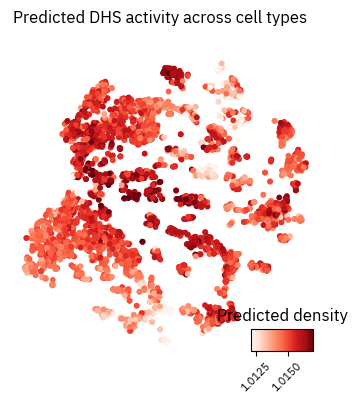

In [252]:
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

values = Y_BCL11A.squeeze().detach().cpu().numpy()

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

sc = ax.scatter(
    embedding_train[:, 0],
    embedding_train[:, 1],
    c=values,
    s=10,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)

axins = inset_axes(ax, width="20%", height="7%", loc="lower right")

axins.set_title("Predicted density")
cbar = fig.colorbar(sc, cax=axins, orientation="horizontal")
for label in cbar.ax.get_xticklabels():
    label.set_rotation(45)
    label.set_fontsize(8)

ax.axis('off')


fig.suptitle("Predicted DHS activity across cell types")


In [253]:
embeddings_file="/home/jvierstra/proj/vinson/data/embeddings.tsv"

pattern = "/net/seq/data2/projects/ENCODE4Plus/hotspot3/human/dnase/peak_calls.v23/{x}/{x}.normalized_density.bw"

density_extr = SamplesDensityExtractor(embeddings_file, pattern)

dens = density_extr[interval.center]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4159/4159 [00:00<00:00, 6425.98it/s]


Text(0.5, 0.98, 'Observed DHS activity across cell types')

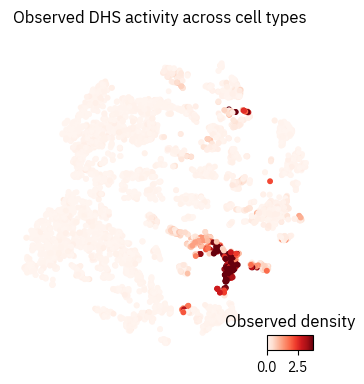

In [254]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)


values = dens

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile

sc = ax.scatter(
    embedding_train[:, 0],
    embedding_train[:, 1],
    s=10,
    c=values,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
axins = inset_axes(
    ax,
    width="15%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Observed density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")
ax.axis('off')


fig.suptitle("Observed DHS activity across cell types")


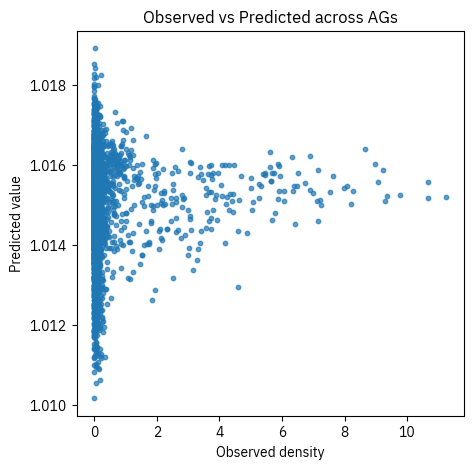

In [255]:
pred_1d = Y_BCL11A.squeeze().detach().cpu().numpy()

# make sure dens is aligned
dens_1d = dens.values

# scatter plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(dens_1d, pred_1d, s=10, alpha=0.7)

ax.set_xlabel("Observed density")
ax.set_ylabel("Predicted value")
ax.set_title("Observed vs Predicted across AGs")

plt.show()


In [256]:
r, p = pearsonr(dens_1d,pred_1d)
print(f"Pearson r = {r:.3f}, p = {p:.2e}")


Pearson r = 0.066, p = 2.23e-05


In [257]:
# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

tensor([6.9849e-10, 1.1874e-08, 1.5832e-08, 1.9558e-08, 2.2235e-08, 1.4144e-08,
        6.8685e-09, 6.7521e-09, 2.1828e-08, 1.0477e-08, 7.7416e-09, 7.6834e-09,
        1.0798e-08, 2.3516e-08, 1.3970e-08, 3.9581e-09, 1.5367e-08, 1.5367e-08,
        9.7789e-09, 3.0850e-09], grad_fn=<AbsBackward0>)


In [200]:
start = interval.start
overlap = 44398486

In [201]:
start-overlap

-643

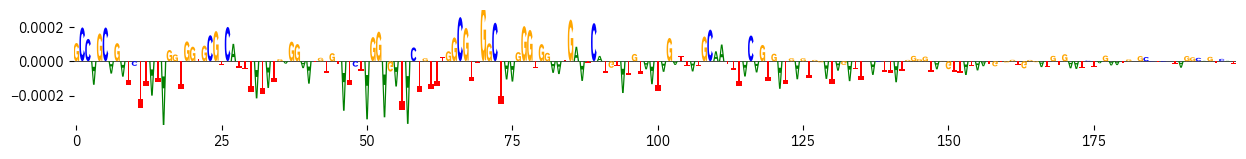

In [203]:
# Plot averaged SHAP scores
fig, ax = plt.subplots()
#use mean_attrs for cell type consensus 
#use attrs[0] for random dataset value

plot_logo(attrs[0][:,625:825], ax=ax)  # Adjusted region
ax.set_ylim(top=0.0003)
fig.set_size_inches(15, 1.5)
plt.show()

In [213]:
# # --- Load the MAF alignment ---
# import subprocess
# hal_file = '/net/seq/data2/projects/jvierstra/annotations/zoonomia/241-mammalian-2020v2.hal'
# ref_genome = 'Homo_sapiens'   # human is now reference
# target_genome = 'Mus_musculus'  # mouse is target
# ref_chrom = "chr4"   # human chr5
# start = 172480547     # human coordinate
# length = 150
# maf_file = '/home/mbrannon/tmp/output_region.maf'

# hal2maf_path = '/home/mbrannon/.local/miniconda3/envs/cactus_env/bin/hal2maf'

# print("Running hal2maf...")
# result = subprocess.run([
#     hal2maf_path,
#     hal_file,
#     maf_file,
#     '--refGenome', ref_genome,
#     '--refSequence', ref_chrom,
#     '--start', str(start),
#     '--length', str(length),
#     '--targetGenomes', target_genome
# ], capture_output=True, text=True)



# human_seq = []
# mouse_seq = []

# with open(maf_file) as f:
#     for line in f:
#         line = line.rstrip()  # only remove trailing spaces, keep leading spaces
#         if not line or line.startswith("#") or line.startswith("a"):
#             continue
#         if line.lstrip().startswith("s"):  # check after removing leading spaces
#             parts = line.split()
#             species = parts[1].split(".")[0]  # e.g., Homo_sapiens
#             seq = parts[6].replace("-", "").upper()  # remove gaps
#             if species == "Homo_sapiens":
#                 human_seq.append(seq)
#             elif species == "Mus_musculus":
#                 mouse_seq.append(seq)

# human_seq = "".join(human_seq)
# mouse_seq = "".join(mouse_seq)

# print("Final sequences length:", len(human_seq), len(mouse_seq))
# print("Seq1 (first 50 bp):", human_seq[:50])
# print("Seq2 (first 50 bp):", mouse_seq[:50])

# # Define letter plotting functions
# def plot_a(ax, base, left_edge, height, color):
#     ax.text(left_edge + 0.5, base + height/2, "A", color=color, fontsize=12,
#             fontweight="bold", ha="center", va="center")

# def plot_c(ax, base, left_edge, height, color):
#     ax.text(left_edge + 0.5, base + height/2, "C", color=color, fontsize=12,
#             fontweight="bold", ha="center", va="center")

# def plot_g(ax, base, left_edge, height, color):
#     ax.text(left_edge + 0.5, base + height/2, "G", color=color, fontsize=12,
#             fontweight="bold", ha="center", va="center")

# def plot_t(ax, base, left_edge, height, color):
#     ax.text(left_edge + 0.5, base + height/2, "T", color=color, fontsize=12,
#             fontweight="bold", ha="center", va="center")

# # Mapping letters to functions and colors
# letter_to_func = {"A": plot_a, "C": plot_c, "G": plot_g, "T": plot_t}
# letter_to_color = {"A": "green", "C": "blue", "G": "orange", "T": "red"}

# seq1 = human_seq
# seq2 = mouse_seq
# height = 1.0

# fig, ax = plt.subplots(figsize=(15, 2))

# # Plot top sequence
# for i, nt in enumerate(seq1):
#     if nt in letter_to_func:
#         letter_to_func[nt](ax, 0, i, height, letter_to_color[nt])

# # Plot bottom sequence
# for i, nt in enumerate(seq2):
#     if nt in letter_to_func:
#         letter_to_func[nt](ax, -height, i, height, letter_to_color[nt])

# ax.set_xlim(0, len(seq1))
# ax.set_ylim(-height*1.5, height*1.5)
# ax.axis('off')
# plt.show()


In [121]:
recip_df = pd.read_table("/net/seq/data2/projects/aabisheva/DHS_evolution/benchmark/hg38_v23_vs_mm39_v2_reciprocal_mapping/fixed_size_summit_over/reciprocal-peaks.correct_ids.txt", names=['chr','start','end','chunk', 'mchr','mstart','mend','mchunk','num'])

In [204]:
recip_df[recip_df['chunk']=='chunk1565_2917_2']

,chr,start,end,chunk,mchr,mstart,mend,mchunk,num
563852,chr20,44398437,44398587,chunk1565_2917_2,chr2,163544041,163544191,chunk3155_2532_1,563853


In [258]:
#mouse
fasta_file = "/net/seq/data/genomes/ENCODE3/mm10/male/mm10-encode3-male.fa"  
fasta_extr = FastaExtractor(fasta_file)
interval = GenomicInterval("chr2",58486684,58486834)
mid = (interval.start + interval.end) // 2
interval = GenomicInterval(interval.chrom, mid, mid).widen(672)
m_embedfile = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/mouse/embeddings.tsv"
m_embeddings_df = pd.read_csv(m_embedfile, sep="\t", index_col=0)
ag_want = 'AG2207'
filtered_embedding = m_embeddings_df[ag_want].values

Y_embed = torch.tensor(filtered_embedding, dtype=torch.float32).unsqueeze(0)




In [216]:
mouse_start = interval.start
overlap_start = 163543917

In [217]:
mouse_start-overlap_start

-473

In [218]:
m_Xregion = intervals_to_ohe(interval, seqlen=1344, fasta_extr=fasta_extr)

## choose which seq and embed to use
m_X = torch.tensor(m_Xregion, dtype=torch.float32)

#m_Y_embed = (torch.as_tensor(m_embeddings_df.T.values, dtype=torch.float32))
m_Y_embed = Y_embed

In [219]:
# Run DeepLIFT/SHAP
m_attrs = deep_lift_shap(
    model_wrapper,
    m_X,
    args=(m_Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

tensor([3.1665e-08, 4.4703e-08, 2.9802e-08, 1.8626e-09, 2.2352e-08, 1.4901e-08,
        1.3970e-08, 8.9407e-08, 5.9605e-08, 7.4506e-09, 3.3528e-08, 2.9802e-08,
        3.7253e-09, 0.0000e+00, 2.9802e-08, 9.3132e-09, 2.1420e-08, 2.1420e-08,
        2.9337e-08, 5.4017e-08], grad_fn=<AbsBackward0>)


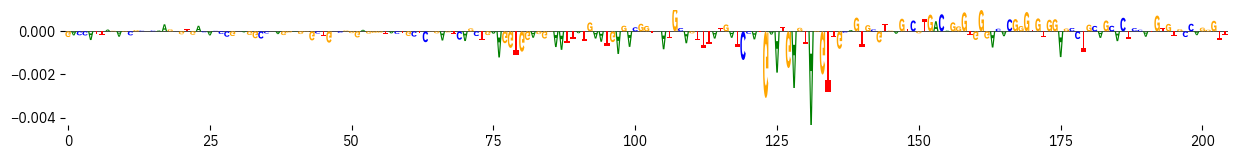

In [236]:
# Plot averaged SHAP scores
fig, ax = plt.subplots()
#use mean_attrs for cell type consensus 
#use attrs[0] for random dataset value
plot_logo(m_attrs[0][:, 495:700], ax=ax)  # Adjusted region
ax.set_ylim(top=0.001)
fig.set_size_inches(15, 1.5)
plt.show()

In [259]:
m_predicted = apply_pairwise(
    predict, 
    model_wrapper, 
    torch.as_tensor(m_Xregion, dtype=torch.float32), 
    args=(torch.as_tensor(m_embeddings_df.T.values, dtype=torch.float32),),
    device="cpu", 
    verbose=True
)

538it [00:01, 501.39it/s]


In [260]:
# #get embeddings 
# from openTSNE import TSNE

# mtsne = TSNE(
#     perplexity=20,
#     metric="euclidean",
#     n_jobs=1,
#     random_state=42,
#     verbose=True,
# )

# m_embedding_train = mtsne.fit(m_embeddings_df.T.to_numpy())

Text(0.5, 0.98, 'Predicted DHS activity across cell types')

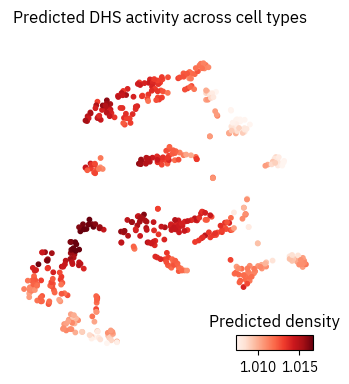

In [261]:
from matplotlib import colors

fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

values = m_predicted

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile


sc = ax.scatter(
    m_embedding_train[:, 0],
    m_embedding_train[:, 1],
    s=10,
    c=values,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)

axins = inset_axes(
    ax,
    width="25%",   # make wider
    height="5%",  # make taller
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Predicted density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.axis('off')

fig.suptitle("Predicted DHS activity across cell types")



In [262]:
pattern = '/net/seq/data2/projects/ENCODE4Plus/hotspot3/mouse/output/{x}/{x}.normalized_density.bw'

density_extr = SamplesDensityExtractor(m_embedfile, pattern)

m_dens = density_extr[interval.center]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 538/538 [00:00<00:00, 6038.33it/s]


Text(0.5, 0.98, 'Observed DHS activity across cell types')

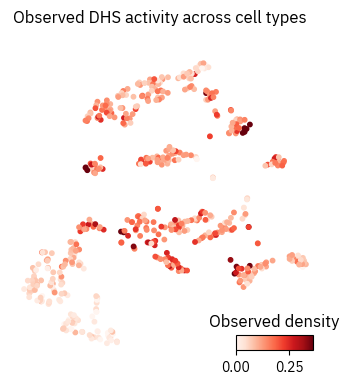

In [263]:
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)

values = m_dens

# set vmin/vmax by percentiles
vmin = np.percentile(values, 2)    # 2nd percentile
vmax = np.percentile(values, 98)   # 98th percentile


sc = ax.scatter(
    m_embedding_train[:, 0],
    m_embedding_train[:, 1],
    s=10,
    c=values,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
axins = inset_axes(
    ax,
    width="25%",   # make wider
    height="5%",  # make taller
    loc="lower right",
)
fig.colorbar(sc, cax=axins, orientation="horizontal")
axins.set_title("Observed density")

# ax.set_title(f"{chrom[i]}:{mid[i]}")

ax.axis('off')

fig.suptitle("Observed DHS activity across cell types")


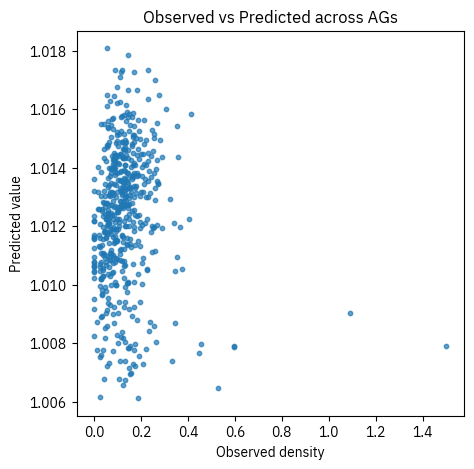

In [264]:
m_pred_1d = m_predicted.squeeze().detach().cpu().numpy()

# make sure dens is aligned
m_dens_1d = m_dens.values

# scatter plot
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(m_dens_1d, m_pred_1d, s=10, alpha=0.7)

ax.set_xlabel("Observed density")
ax.set_ylabel("Predicted value")
ax.set_title("Observed vs Predicted across AGs")

plt.show()


In [265]:
r, p = pearsonr(m_dens_1d, m_pred_1d)
print(f"Pearson r = {r:.3f}, p = {p:.2e}")


Pearson r = -0.026, p = 5.50e-01
